# MAST mesh generator

Builds a TokaMaker gs_Domain mesh from FAIR-MAST's level2 device geometry (pf_active, wall), following the same pattern as the OFT NSTX-U mesh generator example. Legacy MAST geometry only for now (shotRangeStop=40000 in the source metadata).

Each named coil pack (`sol`, `p4_lower`, etc) in `pf_active` is stored as many individual current filaments. Merges each pack into one bounding region with `nTurns` set to the filament count, matching how the reference examples treat a physical coil.

In [ ]:
import os
import sys

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
# Chose this shot because it is what they use in their examples and has all features
shot_id = 30421
shot_url = f'https://s3.echo.stfc.ac.uk/mast/level2/shots/{shot_id}.zarr'

plasma_dx = 0.04
coil_dx = 0.02
vac_dx = 0.12

In [ ]:
ds_pf = xr.open_zarr(shot_url, group='pf_active')
ds_wall = xr.open_zarr(shot_url, group='wall')

coilNames = sorted(set(v.rsplit('_', 1)[0] for v in ds_pf.data_vars if v.endswith('_r')))

limiter = np.column_stack([ds_wall['limiter_r'].values, ds_wall['limiter_z'].values])[:-1]  # drop repeated closing point

In [ ]:
def boundingRectangle(r, z, w, h):
    # One polygon spanning every filament element in a coil pack
    rmin, rmax = (r - abs(w)/2).min(), (r + abs(w)/2).max()
    zmin, zmax = (z - h/2).min(), (z + h/2).max()
    return np.array([[rmin, zmin], [rmax, zmin], [rmax, zmax], [rmin, zmax]])

In [ ]:
gs_mesh = gs_Domain(zpad=[1.2, 1.2], rpad=1.1)
gs_mesh.define_region('air', vac_dx, 'boundary')
gs_mesh.define_region('plasma', plasma_dx, 'plasma')

# One region per physical coil pack, nTurns set to its filament count
for name in coilNames:
    n = ds_pf[f'{name}_r'].size
    gs_mesh.define_region(name, coil_dx, 'coil', nTurns=n, coil_set=name.upper())

In [6]:
gs_mesh.add_polygon(limiter, 'plasma', parent_name='air')

for name in coilNames:
    r, z, w, h = (ds_pf[f'{name}_{k}'].values for k in ('r', 'z', 'width', 'height'))
    gs_mesh.add_polygon(boundingRectangle(r, z, w, h), name, parent_name='air')

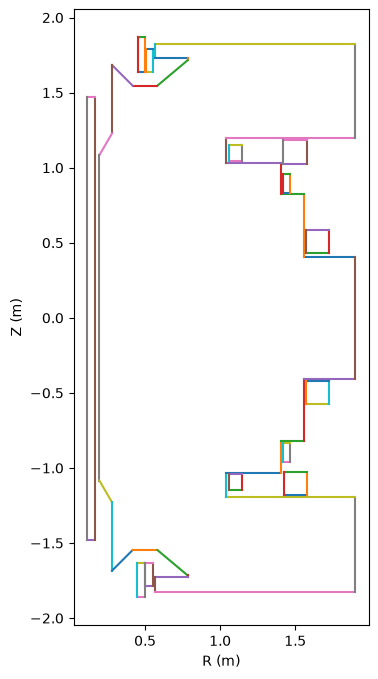

In [7]:
fig, ax = plt.subplots(figsize=(5, 8))
gs_mesh.plot_topology(fig, ax)

In [8]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
coil_dict = gs_mesh.get_coils()
cond_dict = gs_mesh.get_conductors()

Assembling regions:
  # of unique points    = 1038
  # of unique segments  = 92
Generating mesh with Triangle:
  # of points  = 7275
  # of cells   = 14440
  # of regions = 15


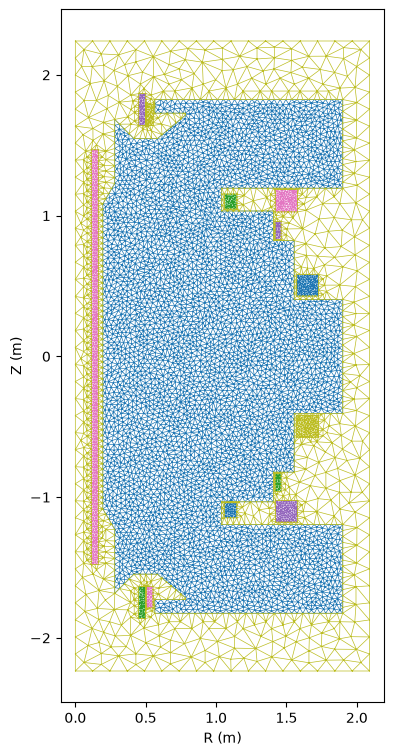

In [11]:
fig, ax = plt.subplots(figsize=(6, 9))
gs_mesh.plot_mesh(fig, ax, show_legends=False)
ax.set_aspect('equal')

In [10]:
save_gs_mesh(mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict, 'MAST_mesh.h5')